In [1]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.stats import chi2


def run_pov_pvalue(channel):
    flat = channel.flatten()
    hist = np.bincount(flat, minlength=256)
    chi_stat = 0.0
    dof = 0
    for k in range(128):
        c0, c1 = hist[2 * k], hist[2 * k + 1]
        total = c0 + c1
        if total > 0:
            exp = total / 2.0
            chi_stat += ((c0 - exp) ** 2 + ((c1 - exp) ** 2)) / exp
            dof += 1
    return 1.0 - chi2.cdf(chi_stat, dof - 1) if dof > 1 else 0.0


def run_rs_diff(channel):
    h, w = channel.shape
    total_groups = (h * w) // 4
    if total_groups == 0:
        return 0.0
    flat = channel.flatten()[: total_groups * 4].reshape(-1, 4)
    mask = np.array([0, 1, 1, 0], dtype=np.int32)
    neg_mask = -mask

    def flip(val, m):
        if m == 1:
            return val ^ 1
        elif m == -1:
            return (val - 1) if (val % 2 == 0) else (val + 1)
        return val

    r_m = r_neg = s_m = s_neg = 0
    for g in flat:
        v = np.sum(np.abs(g[1:] - g[:-1]))
        gm = np.array([flip(g[i], mask[i]) for i in range(4)])
        gneg = np.array([flip(g[i], neg_mask[i]) for i in range(4)])
        vm = np.sum(np.abs(gm[1:] - gm[:-1]))
        vneg = np.sum(np.abs(gneg[1:] - gneg[:-1]))

        if vm > v:
            r_m += 1
        elif vm < v:
            s_m += 1
        if vneg > v:
            r_neg += 1
        elif vneg < v:
            s_neg += 1

    return abs((r_m - s_m) / total_groups - (r_neg - s_neg) / total_groups)


def run_sp_rate(channel):
    u = channel[:, :-1].astype(np.int32).flatten()
    v = channel[:, 1:].astype(np.int32).flatten()
    diff = np.abs(u - v)
    same_interval = (u // 2) == (v // 2)

    gamma = np.sum(diff == 0)
    x = np.sum(same_interval & (u != v))
    y = np.sum((diff == 1) & (~same_interval))
    z = np.sum((diff > 1) & (u % 2 != v % 2))

    a = 0.5 * (gamma + x)
    b = 2 * x - y
    c = y - z

    disc = b**2 - 4 * a * c
    if disc >= 0 and a != 0:
        r1 = (-b + math.sqrt(disc)) / (2 * a)
        r2 = (-b - math.sqrt(disc)) / (2 * a)
        valid = [r for r in (r1, r2) if 0.0 <= r <= 1.0]
        if valid:
            return min(valid)
    return 0.0


def run_lr_score(channel):
    flat = channel.astype(np.float64).flatten()
    u, v = flat[:-1], flat[1:]
    clean_d = np.mean(np.abs(u - v))
    if clean_d == 0:
        return 0.0
    u_f = u.astype(np.int32) ^ 1
    v_f = v.astype(np.int32) ^ 1
    flipped_d = np.mean(np.abs(u_f - v_f))
    return (flipped_d - clean_d) / clean_d

In [2]:
TARGET_DIR = "test_files"

image_files = []
for root, _, files in os.walk(TARGET_DIR):
    for f in sorted(files):
        full_p = os.path.join(root, f)
        try:
            with Image.open(full_p) as im:
                im.verify()
            image_files.append(full_p)
        except Exception:
            continue

header = f"{'IMAGE FILE':<35} {'PoV P-VAL':<12} {'RS |d0-d-|':<12} {'SP RATE':<12} {'LR SCORE':<12} {'VERDICT'}"
print(header)
print("-" * len(header))

for img_path in image_files:
    with Image.open(img_path) as im:
        gray = np.array(im.convert("L"), dtype=np.int32)

    pov_p = run_pov_pvalue(gray)
    rs_diff = run_rs_diff(gray)
    sp_p = run_sp_rate(gray)
    lr_sc = run_lr_score(gray)

    anomalies = 0
    if pov_p > 0.8:
        anomalies += 1
    if rs_diff > 0.05:
        anomalies += 1
    if sp_p > 0.08:
        anomalies += 1
    if lr_sc < 0.02:
        anomalies += 1

    verdict = "SUSPICIOUS" if anomalies >= 2 else "CLEAN"
    fname = os.path.basename(img_path)
    if len(fname) > 33:
        fname = fname[:30] + "..."

    print(
        f"{fname:<35} {pov_p:<12.4f} {rs_diff:<12.4f} {sp_p:<12.2%} {lr_sc:<12.4f} {verdict}"
    )

/home/jon/Projects/Cyber-Forensics/.direnv/python-3.14/lib/python3.14/site-packages/PIL/IcoImagePlugin.py:372: UserWarning: Image was not the expected size
  warnings.warn("Image was not the expected size")


IMAGE FILE                          PoV P-VAL    RS |d0-d-|   SP RATE      LR SCORE     VERDICT
-----------------------------------------------------------------------------------------------
Grand Theft Auto VI Trailer 1.mp4   0.0000       0.0030       68.53%       0.0246       CLEAN
Grand Theft Auto VI Trailer 1_...   0.0000       0.0030       68.53%       0.0246       CLEAN
blank_recovered.png                 0.0000       0.0372       8.66%        0.0085       SUSPICIOUS
gta_v_iceberg_unexplained.jpg       0.0000       0.0021       15.78%       0.0522       CLEAN
look_what_they_need_to_mimic_a...   0.0000       0.0088       0.00%        0.1129       CLEAN
mr_incredible_becoming_uncanny...   0.0000       0.0079       0.00%        0.0636       CLEAN
291784886fe3eb37d7d48f2a60564a...   0.0000       0.0036       38.80%       0.0427       CLEAN
291784886fe3eb37d7d48f2a60564a...   0.0000       0.0036       38.80%       0.0427       CLEAN
857f75db04db84340d4efa53061ca2...   0.0000       0.

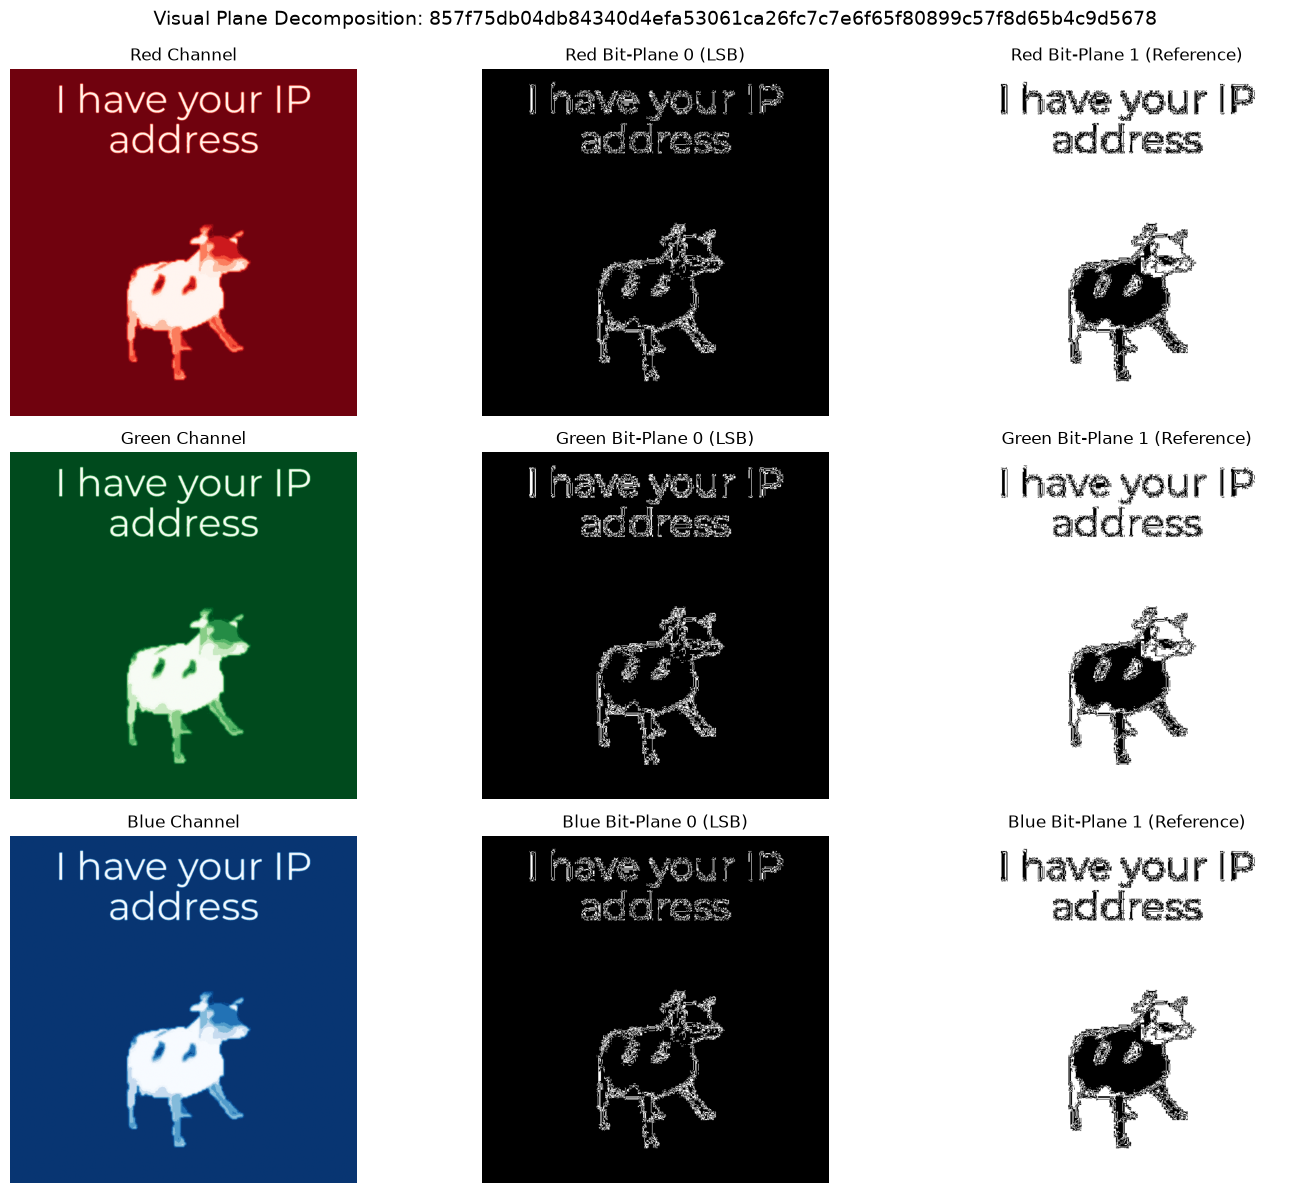

In [9]:
TARGET_IMAGE = "test_files/from_web/857f75db04db84340d4efa53061ca26fc7c7e6f65f80899c57f8d65b4c9d5678"  # or your recovered path

raw_img = Image.open(TARGET_IMAGE).convert("RGB")
arr = np.array(raw_img)

channels = ["Red", "Green", "Blue"]
cmaps = ["Reds", "Greens", "Blues"]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, (ch_name, cmap_name) in enumerate(zip(channels, cmaps)):
    ch_data = arr[:, :, i]
    lsb_plane = (ch_data & 1) * 255
    bit1_plane = ((ch_data >> 1) & 1) * 255

    axes[i, 0].imshow(ch_data, cmap=cmap_name)
    axes[i, 0].set_title(f"{ch_name} Channel")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(lsb_plane, cmap="gray")
    axes[i, 1].set_title(f"{ch_name} Bit-Plane 0 (LSB)")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(bit1_plane, cmap="gray")
    axes[i, 2].set_title(f"{ch_name} Bit-Plane 1 (Reference)")
    axes[i, 2].axis("off")

plt.suptitle(
    f"Visual Plane Decomposition: {os.path.basename(TARGET_IMAGE)}",
    fontsize=14,
    y=0.99,
)
plt.tight_layout()
plt.show()

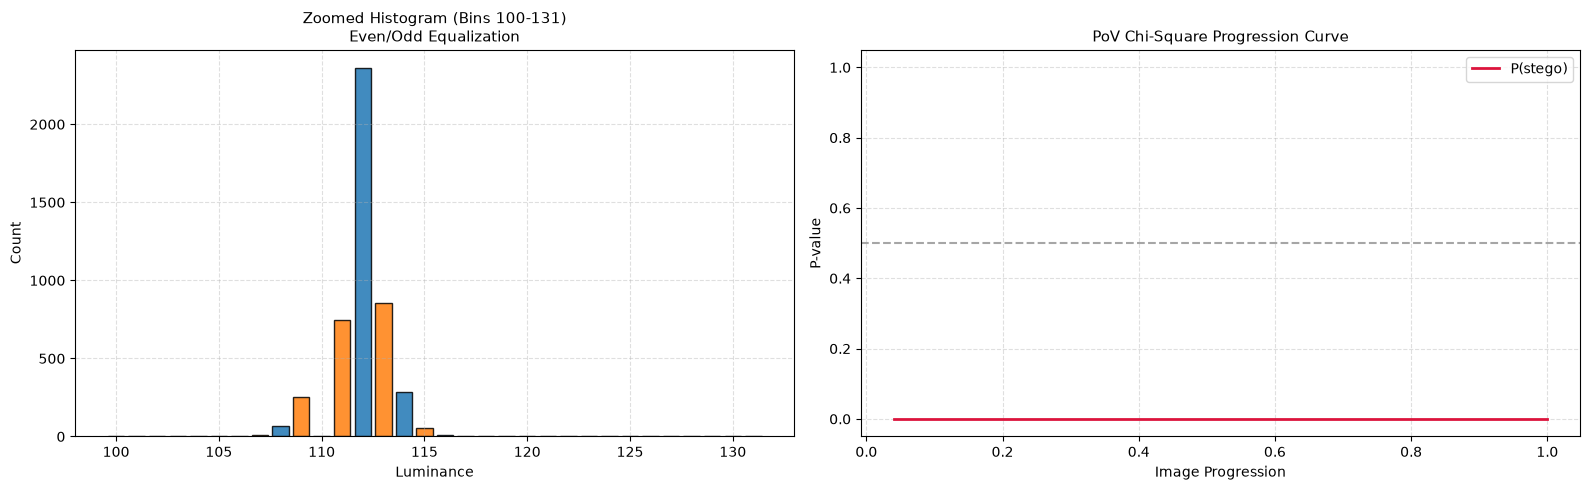

In [10]:
raw_img = Image.open(TARGET_IMAGE).convert("RGB")
gray = np.array(raw_img.convert("L"), dtype=np.int32)
flat = gray.flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histogram Pair-of-Values Step Equalization
bins_range = np.arange(100, 132)
hist, _ = np.histogram(flat, bins=np.arange(100, 133))
bar_colors = ["#1f77b4" if i % 2 == 0 else "#ff7f0e" for i in range(len(bins_range))]

axes[0].bar(
    bins_range,
    hist,
    color=bar_colors,
    width=0.8,
    edgecolor="black",
    alpha=0.85,
)
axes[0].set_title("Zoomed Histogram (Bins 100-131)\nEven/Odd Equalization", fontsize=11)
axes[0].set_xlabel("Luminance")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.4)

# Plot 2: Cumulative PoV Chi-Square Progression Curve
step = max(512, len(flat) // 100)
p_vals, sample_fractions = [], []

for end in range(step, len(flat) + 1, step):
    sub = flat[:end]
    h = np.bincount(sub, minlength=256)
    stat = 0.0
    dof = 0
    for k in range(128):
        c0, c1 = h[2 * k], h[2 * k + 1]
        tot = c0 + c1
        if tot > 0:
            exp = tot / 2.0
            stat += ((c0 - exp) ** 2 + (c1 - exp) ** 2) / exp
            dof += 1
    if dof > 1:
        p_vals.append(1.0 - chi2.cdf(stat, dof - 1))
        sample_fractions.append(end / len(flat))

axes[1].plot(sample_fractions, p_vals, color="crimson", lw=2, label="P(stego)")
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.7)
axes[1].set_title("PoV Chi-Square Progression Curve", fontsize=11)
axes[1].set_xlabel("Image Progression")
axes[1].set_ylabel("P-value")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()